# Initial Report and Exploratory Data Analysis

## Project: Impact of 5G Signal Strength on Voice Quality

**Research question:** How does RSRP affect MOS across the n1, n28, and n78 bands within one 5G field-test collection?

This notebook performs data cleaning, exploratory analysis, feature engineering, visualization, and baseline regression modeling.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


## 1. Load the data

Export the joined MOS and radio data to:

`data/mos_rsrp_5g.csv`

The code accepts several common source-column names and standardizes them automatically.


In [2]:
DATA_PATH = Path("../data/mos_rsrp_5g.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Export the SQL result to data/mos_rsrp_5g.csv and run the notebook again."
    )

raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")
raw_df.head()


Raw shape: (1812, 10)


,CollectionName,SessionId,TestId,Timestamp,RFBand,MOS,RSRP Rx,SINR Rx,RSRQ Rx,DataType
0,SYNTHETIC_5G_VOICE_2026,1001,1,2026-06-15 09:00:00,n28,3.385,-101.470,6.380,-15.160,SYNTHETIC
1,SYNTHETIC_5G_VOICE_2026,1001,2,2026-06-15 09:00:05,n28,3.313,-112.730,3.740,-15.900,SYNTHETIC
2,SYNTHETIC_5G_VOICE_2026,1001,3,2026-06-15 09:00:10,n28,3.387,-98.890,10.180,-15.480,SYNTHETIC
3,SYNTHETIC_5G_VOICE_2026,1001,4,2026-06-15 09:00:15,n28,3.533,-108.620,-1.920,-19.490,SYNTHETIC
4,SYNTHETIC_5G_VOICE_2026,1001,5,2026-06-15 09:00:20,n28,3.743,-99.370,6.830,-15.440,SYNTHETIC


In [3]:
COLUMN_CANDIDATES = {
    "collection": ["CollectionName", "collection_name", "collection"],
    "session_id": ["SessionId", "session_id"],
    "test_id": ["TestId", "test_id"],
    "timestamp": ["Timestamp", "MsgTime", "Time", "timestamp"],
    "band": ["RFBand", "Band", "NRBand", "band"],
    "mos": ["MOS", "LQ", "mos"],
    "rsrp": ["RSRP Rx", "RSRP_Rx", "RSRP", "rsrp"],
    "sinr": ["SINR Rx", "SINR_Rx", "SINR", "sinr"],
    "rsrq": ["RSRQ Rx", "RSRQ_Rx", "RSRQ", "rsrq"],
}

def select_available_columns(frame, candidates):
    selected = {}
    for standard_name, possible_names in candidates.items():
        source_name = next((name for name in possible_names if name in frame.columns), None)
        if source_name is not None:
            selected[standard_name] = frame[source_name]
    return pd.DataFrame(selected)

df = select_available_columns(raw_df, COLUMN_CANDIDATES)

required = {"band", "mos", "rsrp"}
missing_required = required.difference(df.columns)
if missing_required:
    raise ValueError(
        f"Missing required standardized columns: {sorted(missing_required)}. "
        f"Available source columns: {raw_df.columns.tolist()}"
    )

print("Standardized columns:", df.columns.tolist())
df.head()


Standardized columns: ['collection', 'session_id', 'test_id', 'timestamp', 'band', 'mos', 'rsrp', 'sinr', 'rsrq']


,collection,session_id,test_id,timestamp,band,mos,rsrp,sinr,rsrq
0,SYNTHETIC_5G_VOICE_2026,1001,1,2026-06-15 09:00:00,n28,3.385,-101.470,6.380,-15.160
1,SYNTHETIC_5G_VOICE_2026,1001,2,2026-06-15 09:00:05,n28,3.313,-112.730,3.740,-15.900
2,SYNTHETIC_5G_VOICE_2026,1001,3,2026-06-15 09:00:10,n28,3.387,-98.890,10.180,-15.480
3,SYNTHETIC_5G_VOICE_2026,1001,4,2026-06-15 09:00:15,n28,3.533,-108.620,-1.920,-19.490
4,SYNTHETIC_5G_VOICE_2026,1001,5,2026-06-15 09:00:20,n28,3.743,-99.370,6.830,-15.440


## 2. Initial inspection


In [4]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing_values"))
print(f"Exact duplicate rows: {df.duplicated().sum():,}")


Rows: 1,812
Columns: 9


,collection,session_id,test_id,timestamp,band,mos,rsrp,sinr,rsrq
0,SYNTHETIC_5G_VOICE_2026,1001,1,2026-06-15 09:00:00,n28,3.385,-101.470,6.380,-15.160
1,SYNTHETIC_5G_VOICE_2026,1001,2,2026-06-15 09:00:05,n28,3.313,-112.730,3.740,-15.900
2,SYNTHETIC_5G_VOICE_2026,1001,3,2026-06-15 09:00:10,n28,3.387,-98.890,10.180,-15.480
3,SYNTHETIC_5G_VOICE_2026,1001,4,2026-06-15 09:00:15,n28,3.533,-108.620,-1.920,-19.490
4,SYNTHETIC_5G_VOICE_2026,1001,5,2026-06-15 09:00:20,n28,3.743,-99.370,6.830,-15.440


,dtype
collection,object
session_id,int64
test_id,int64
timestamp,object
band,object
mos,float64
rsrp,float64
sinr,float64
rsrq,float64


,missing_values
collection,0
session_id,0
test_id,0
timestamp,0
band,0
mos,8
rsrp,8
sinr,18
rsrq,0


Exact duplicate rows: 12


## 3. Data cleaning

The analysis removes exact duplicates, missing critical values, unsupported bands, and physically implausible values. Outliers are also flagged using the IQR method, but are not automatically removed because extreme radio values may represent real weak-coverage conditions.


In [5]:
def normalize_band(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    match = re.search(r"(?:n|nr)?\s*(1|28|78)(?:\D|$)", text)
    if match:
        return f"n{match.group(1)}"
    return text

df["band"] = df["band"].map(normalize_band)

for column in ["mos", "rsrp", "sinr", "rsrq"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

rows_raw = len(df)
duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

df = df[df["band"].isin(["n1", "n28", "n78"])].copy()
df = df.dropna(subset=["band", "mos", "rsrp"]).copy()

# Domain checks
df = df[df["mos"].between(1, 5)].copy()
df = df[df["rsrp"].between(-160, -40)].copy()

if "sinr" in df.columns:
    df.loc[~df["sinr"].between(-30, 50), "sinr"] = np.nan

if "rsrq" in df.columns:
    df.loc[~df["rsrq"].between(-40, 0), "rsrq"] = np.nan

rows_clean = len(df)

cleaning_summary = pd.Series({
    "raw_rows": rows_raw,
    "duplicates_removed": duplicates,
    "clean_rows": rows_clean,
    "rows_removed_total": rows_raw - rows_clean,
})

cleaning_summary


raw_rows              1812
duplicates_removed      12
clean_rows            1774
rows_removed_total      38
dtype: int64

In [6]:
def add_iqr_flag(frame, value_column, group_column="band"):
    output = frame.copy()
    output[f"{value_column}_iqr_outlier"] = False

    for group, index in output.groupby(group_column).groups.items():
        values = output.loc[index, value_column].dropna()
        if values.empty:
            continue

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        output.loc[index, f"{value_column}_iqr_outlier"] = (
            (output.loc[index, value_column] < lower)
            | (output.loc[index, value_column] > upper)
        )

    return output

df = add_iqr_flag(df, "mos")
df = add_iqr_flag(df, "rsrp")

outlier_summary = df.groupby("band").agg(
    samples=("mos", "size"),
    mos_iqr_outliers=("mos_iqr_outlier", "sum"),
    rsrp_iqr_outliers=("rsrp_iqr_outlier", "sum"),
)

outlier_summary


,samples,mos_iqr_outliers,rsrp_iqr_outliers
band,,,
n1,592,13,10
n28,592,9,4
n78,590,6,3


## 4. Feature engineering


In [7]:
rsrp_bins = [-160, -110, -100, -90, -40]
rsrp_labels = ["< -110", "-110 to -100", "-100 to -90", "> -90"]

df["rsrp_range"] = pd.cut(
    df["rsrp"],
    bins=rsrp_bins,
    labels=rsrp_labels,
    include_lowest=True,
)

df["band"] = pd.Categorical(
    df["band"],
    categories=["n28", "n1", "n78"],
    ordered=True,
)

df.head()


,collection,session_id,test_id,timestamp,band,mos,rsrp,sinr,rsrq,mos_iqr_outlier,rsrp_iqr_outlier,rsrp_range
0,SYNTHETIC_5G_VOICE_2026,1001,1,2026-06-15 09:00:00,n28,3.385,-101.470,6.380,-15.160,False,False,-110 to -100
1,SYNTHETIC_5G_VOICE_2026,1001,2,2026-06-15 09:00:05,n28,3.313,-112.730,3.740,-15.900,False,False,< -110
2,SYNTHETIC_5G_VOICE_2026,1001,3,2026-06-15 09:00:10,n28,3.387,-98.890,10.180,-15.480,False,False,-100 to -90
3,SYNTHETIC_5G_VOICE_2026,1001,4,2026-06-15 09:00:15,n28,3.533,-108.620,-1.920,-19.490,False,False,-110 to -100
4,SYNTHETIC_5G_VOICE_2026,1001,5,2026-06-15 09:00:20,n28,3.743,-99.370,6.830,-15.440,False,False,-100 to -90


## 5. Descriptive statistics


In [8]:
summary_by_band = (
    df.groupby("band", observed=False)
      .agg(
          samples=("mos", "size"),
          mos_mean=("mos", "mean"),
          mos_median=("mos", "median"),
          mos_std=("mos", "std"),
          rsrp_mean=("rsrp", "mean"),
          rsrp_median=("rsrp", "median"),
          rsrp_std=("rsrp", "std"),
      )
)

if "sinr" in df.columns:
    summary_by_band["sinr_mean"] = (
        df.groupby("band", observed=False)["sinr"].mean()
    )

summary_by_band


,samples,mos_mean,mos_median,mos_std,rsrp_mean,rsrp_median,rsrp_std,sinr_mean
band,,,,,,,,
n28,592,3.452,3.485,0.523,-99.683,-99.990,8.563,7.453
n1,592,3.816,3.849,0.478,-93.841,-93.855,7.254,11.407
n78,590,4.163,4.218,0.542,-87.449,-87.305,8.979,16.217


In [10]:
correlation_by_band = (
    df.groupby("band", observed=False)[["rsrp", "mos"]]
      .apply(lambda group: group["rsrp"].corr(group["mos"]))
      .rename("rsrp_mos_correlation")
      .to_frame()
)

correlation_by_band


,rsrp_mos_correlation
band,
n28,0.617
n1,0.554
n78,0.615


## 6. Visualizations


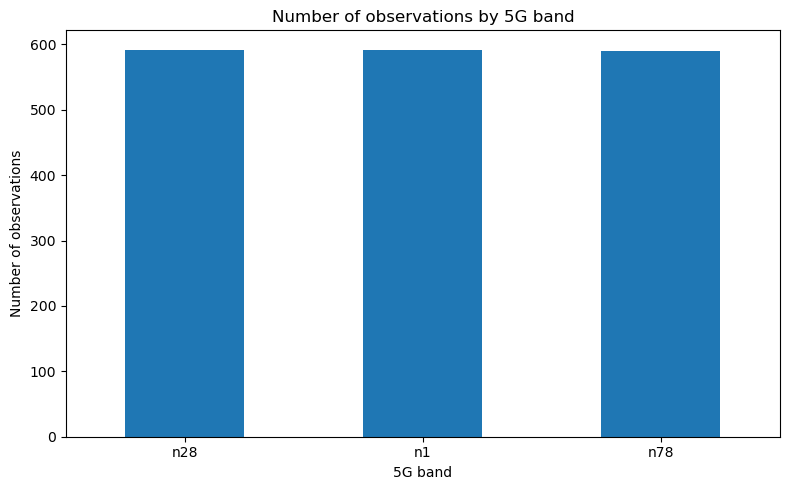

In [11]:
sample_counts = df["band"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
sample_counts.plot(kind="bar", ax=ax)
ax.set_title("Number of observations by 5G band")
ax.set_xlabel("5G band")
ax.set_ylabel("Number of observations")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


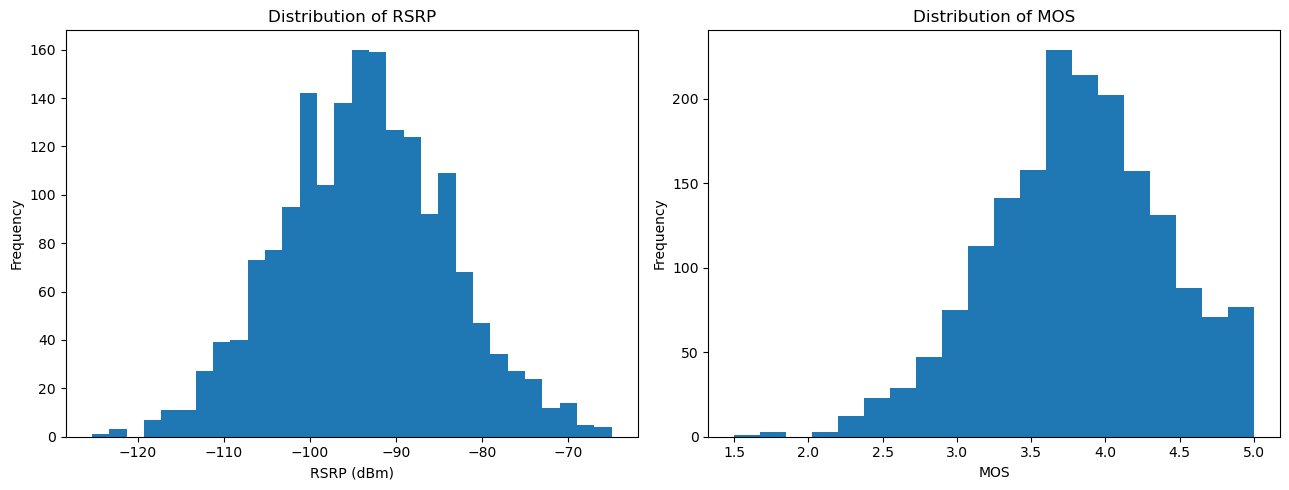

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["rsrp"].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Distribution of RSRP")
axes[0].set_xlabel("RSRP (dBm)")
axes[0].set_ylabel("Frequency")

df["mos"].plot(kind="hist", bins=20, ax=axes[1])
axes[1].set_title("Distribution of MOS")
axes[1].set_xlabel("MOS")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


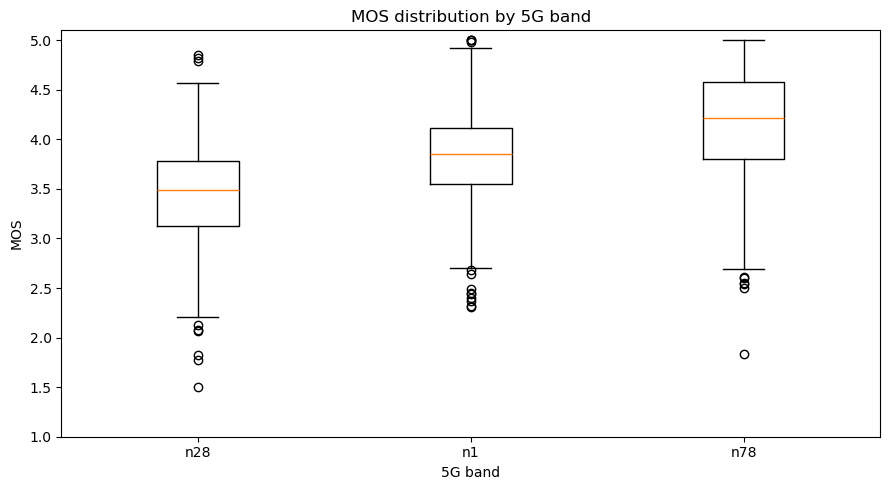

In [14]:
ordered_bands = ["n28", "n1", "n78"]
mos_groups = [
    df.loc[df["band"] == band, "mos"].dropna()
    for band in ordered_bands
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(mos_groups, tick_labels=ordered_bands, showfliers=True)
ax.set_title("MOS distribution by 5G band")
ax.set_xlabel("5G band")
ax.set_ylabel("MOS")
ax.set_ylim(1, 5.1)
plt.tight_layout()
plt.show()


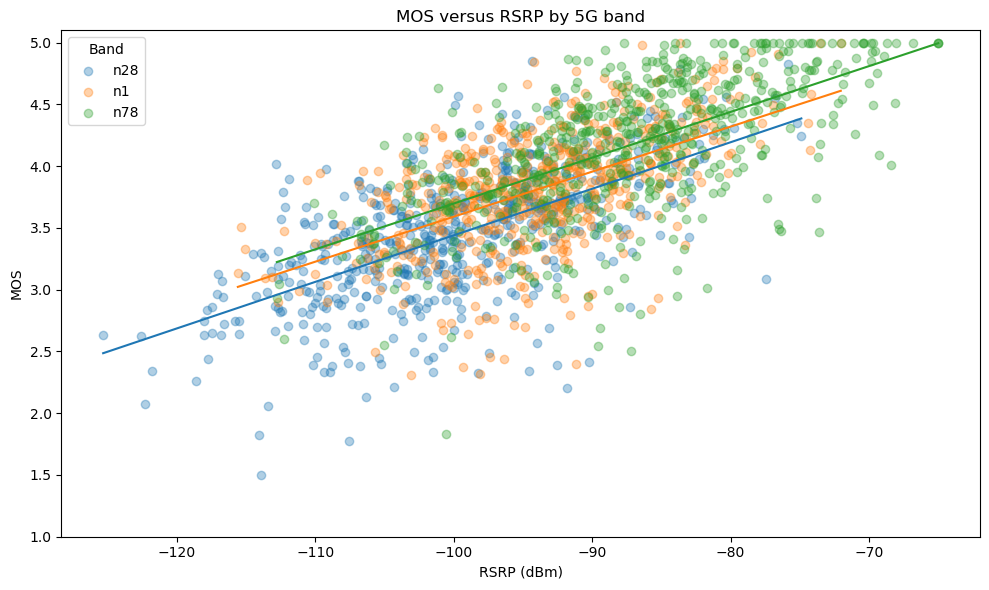

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for band in ordered_bands:
    band_df = df[df["band"] == band].dropna(subset=["rsrp", "mos"])
    ax.scatter(
        band_df["rsrp"],
        band_df["mos"],
        alpha=0.35,
        label=band,
    )

    if len(band_df) >= 2 and band_df["rsrp"].nunique() > 1:
        slope, intercept = np.polyfit(band_df["rsrp"], band_df["mos"], 1)
        x_line = np.linspace(band_df["rsrp"].min(), band_df["rsrp"].max(), 100)
        ax.plot(x_line, slope * x_line + intercept)

ax.set_title("MOS versus RSRP by 5G band")
ax.set_xlabel("RSRP (dBm)")
ax.set_ylabel("MOS")
ax.set_ylim(1, 5.1)
ax.legend(title="Band")
plt.tight_layout()
plt.show()


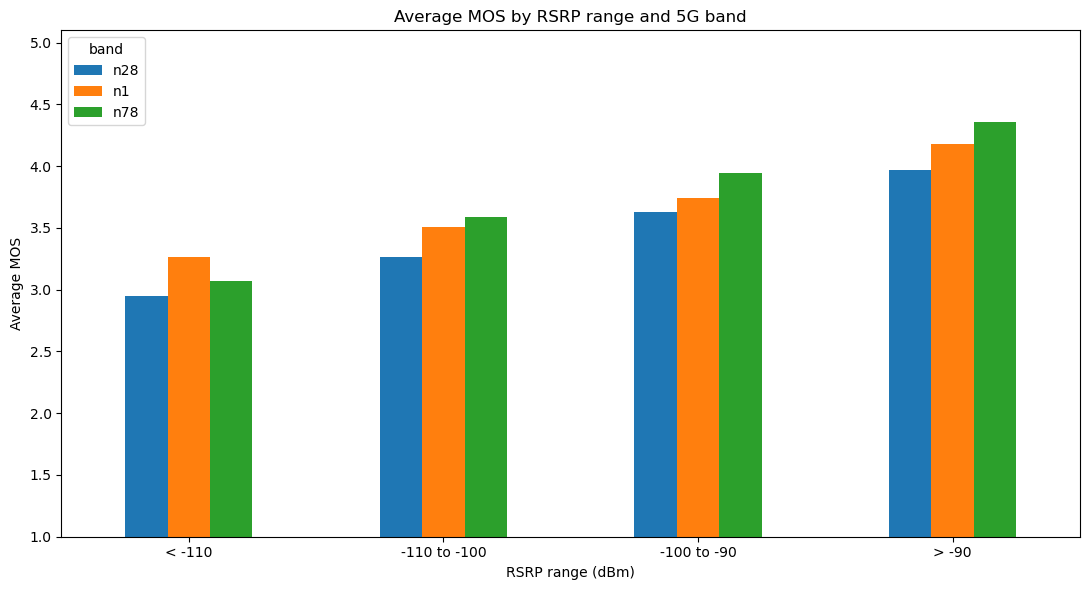

band,n28,n1,n78
rsrp_range,,,
< -110,2.950,3.266,3.070
-110 to -100,3.265,3.504,3.588
-100 to -90,3.627,3.740,3.947
> -90,3.968,4.176,4.362


In [16]:
mos_by_range = (
    df.pivot_table(
        index="rsrp_range",
        columns="band",
        values="mos",
        aggfunc="mean",
        observed=False,
    )
)

ax = mos_by_range.plot(kind="bar", figsize=(11, 6))
ax.set_title("Average MOS by RSRP range and 5G band")
ax.set_xlabel("RSRP range (dBm)")
ax.set_ylabel("Average MOS")
ax.set_ylim(1, 5.1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

mos_by_range


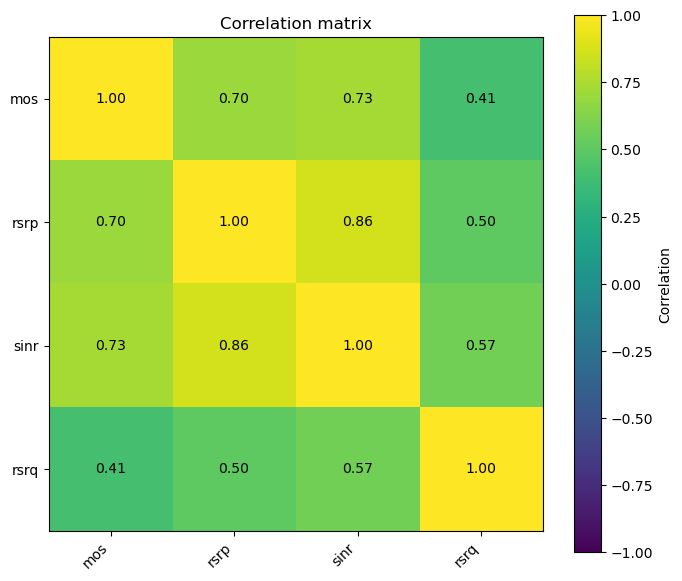

In [17]:
numeric_columns = [
    column for column in ["mos", "rsrp", "sinr", "rsrq"]
    if column in df.columns
]
correlation_matrix = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_columns)), numeric_columns, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_columns)), numeric_columns)
ax.set_title("Correlation matrix")

for row in range(len(numeric_columns)):
    for column in range(len(numeric_columns)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


## 7. Baseline regression model

The target is MOS. Predictors include RSRP, band, and SINR when available.

Metrics:

- **MAE:** average prediction error measured directly in MOS points.
- **RMSE:** gives more weight to large errors.
- **R²:** proportion of MOS variance explained by the model.


In [18]:
feature_columns = ["rsrp", "band"]

if "sinr" in df.columns and df["sinr"].notna().sum() > 0:
    feature_columns.append("sinr")

model_df = df[feature_columns + ["mos"]].copy()

X = model_df[feature_columns]
y = model_df["mos"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

numeric_features = [
    column for column in feature_columns
    if column != "band"
]
categorical_features = ["band"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)


In [19]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(np.zeros((len(y_train), 1)), y_train)
dummy_predictions = dummy_model.predict(np.zeros((len(y_test), 1)))

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

model_results = pd.DataFrame(
    {
        "Mean baseline": regression_metrics(y_test, dummy_predictions),
        "Linear regression": regression_metrics(y_test, linear_predictions),
    }
).T

model_results


,MAE,RMSE,R2
Mean baseline,0.449,0.561,-0.007
Linear regression,0.307,0.395,0.499


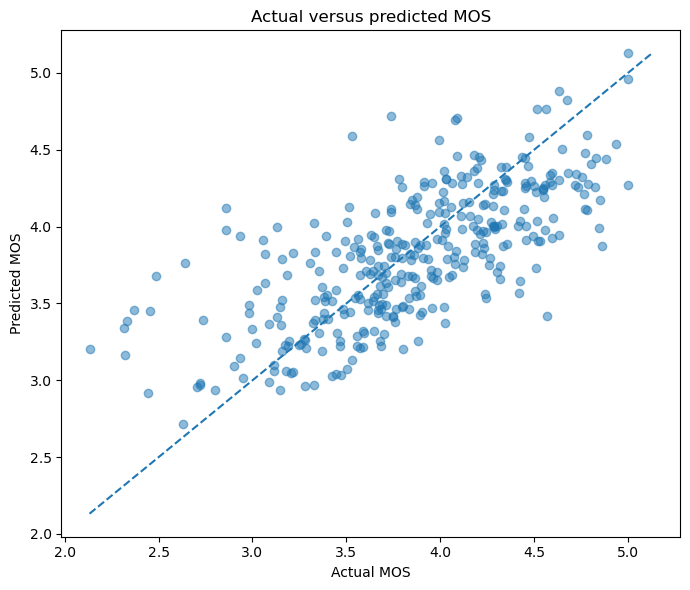

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, linear_predictions, alpha=0.5)

minimum = min(y_test.min(), linear_predictions.min())
maximum = max(y_test.max(), linear_predictions.max())
ax.plot([minimum, maximum], [minimum, maximum], linestyle="--")

ax.set_title("Actual versus predicted MOS")
ax.set_xlabel("Actual MOS")
ax.set_ylabel("Predicted MOS")
plt.tight_layout()
plt.show()


## 8. Model interpretation


In [21]:
fitted_preprocessor = linear_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coefficient_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
    })
    .sort_values("coefficient", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

coefficient_table


,feature,coefficient
0,numeric__sinr,0.266
1,numeric__rsrp,0.162
2,categorical__band_n28,-0.113
3,categorical__band_n78,0.042


## 9. Executive findings for README

Run this cell and paste the generated text into the `Results` section of `README.md`.


In [22]:
band_counts = df["band"].value_counts().sort_index()
highest_mos_band = summary_by_band["mos_mean"].idxmax()

valid_correlations = correlation_by_band["rsrp_mos_correlation"].dropna()
if valid_correlations.empty:
    strongest_band = "not available"
    strongest_correlation = np.nan
else:
    strongest_band = valid_correlations.abs().idxmax()
    strongest_correlation = valid_correlations.loc[strongest_band]

dummy_mae = model_results.loc["Mean baseline", "MAE"]
linear_mae = model_results.loc["Linear regression", "MAE"]
linear_rmse = model_results.loc["Linear regression", "RMSE"]
linear_r2 = model_results.loc["Linear regression", "R2"]

band_count_text = "; ".join(
    f"{band} = {int(band_counts.get(band, 0))}"
    for band in ["n1", "n28", "n78"]
)

relationship_text = (
    "improved on"
    if linear_mae < dummy_mae
    else "did not improve on"
)

results_text = f"""
## Results

- Clean observations analyzed: **{len(df):,}**
- Observations by band: **{band_count_text}**
- Band with the highest average MOS: **{highest_mos_band}**
- Strongest absolute RSRP–MOS correlation: **{strongest_band}, {strongest_correlation:.3f}**
- Mean-prediction baseline MAE: **{dummy_mae:.3f}**
- Linear-regression MAE: **{linear_mae:.3f}**
- Linear-regression RMSE: **{linear_rmse:.3f}**
- Linear-regression R²: **{linear_r2:.3f}**

The regression model {relationship_text} the mean-prediction baseline. The results show how much useful information RSRP, band, and available SINR measurements provide for predicting MOS. Because voice quality may also depend on codec behavior, packet loss, handovers, congestion, and signaling events, these variables should be added in the next modeling stage.
"""

print(results_text)



## Results

- Clean observations analyzed: **1,774**
- Observations by band: **n1 = 592; n28 = 592; n78 = 590**
- Band with the highest average MOS: **n78**
- Strongest absolute RSRP–MOS correlation: **n28, 0.617**
- Mean-prediction baseline MAE: **0.449**
- Linear-regression MAE: **0.307**
- Linear-regression RMSE: **0.395**
- Linear-regression R²: **0.499**

The regression model improved on the mean-prediction baseline. The results show how much useful information RSRP, band, and available SINR measurements provide for predicting MOS. Because voice quality may also depend on codec behavior, packet loss, handovers, congestion, and signaling events, these variables should be added in the next modeling stage.



## 10. Limitations and next steps

- The analysis currently uses one collection, so conclusions may not generalize to other routes or networks.
- Samples from the same session may be correlated.
- RSRP alone may not explain codec, transport, mobility, and congestion effects.
- A stronger next model should use grouped validation by session and add SINR, RSRQ, handovers, packet loss, codec, and call-state features.
